In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from lemon_connectivity.qc import (
    batch_quality_control,
    summarize_batch_quality_control,
)

## Load Data and Verify Starting Inventory
The count is based on every non-missing matrix filename in the union alignment table. This prevents an unmatched matrix from being silently dropped before QC.

In [2]:
fcm_dir = Path("../data/external/Curvature-FCN-Aging/DATA/FCM")
alignment_path = Path("../data/interim/participant_alignment_table.csv")
expected_cohort_size = 225

if not alignment_path.is_file():
    raise FileNotFoundError(f"Alignment table missing: {alignment_path}")
if not fcm_dir.is_dir():
    raise FileNotFoundError(f"FCM directory missing: {fcm_dir}")

alignment_table = pd.read_csv(alignment_path)
observed_fcm_files = int(alignment_table["matrix_filename"].notna().sum())


print("=== INVENTORY VERIFICATION ===")
if observed_fcm_files != expected_cohort_size:
    raise ValueError(
        f"Expected {expected_cohort_size} FCM candidates, found {observed_fcm_files}"
    )
print(f"Verified {observed_fcm_files} FCM candidates for batch QC.")

=== INVENTORY VERIFICATION ===
Verified 225 FCM candidates for batch QC.


## Batch Quality Control

In [3]:
qc_results_df = batch_quality_control(
    alignment_table, 
    fcm_dir,
    n_rois=200,
    expected_files=expected_cohort_size,
)

if len(qc_results_df) != expected_cohort_size:
    raise AssertionError("Not every FCM candidate received a QC record")
if qc_results_df["canonical_id"].duplicated().any():
    raise AssertionError("QC ledger contains duplicated canonical IDs")

output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)
qc_results_df.to_csv(output_dir / "batch_fcm_qc_report.csv", index=False)

print(f"Saved the local participant-level QC ledger to {output_dir}")

Saved the local participant-level QC ledger to ../data/processed


## Aggregate QC Summary

Only aggregate counts are displayed. Participant IDs and filenames are intentionally not rendered into committed notebook output.

In [4]:
load_summary = summarize_batch_quality_control(qc_results_df)
load_summary.to_frame(name="count")



failure_summary = (
    qc_results_df.loc[~qc_results_df["qc_passed"], "failure_code"]
    .fillna("unspecified")
    .value_counts()
    .rename_axis("failure_code")
    .reset_index(name="count")
)

failure_summary

,failure_code,count


## Define the retained sample

The rule is prespecified and independent of age, sex, cohort, cognition, or any downstream result: retain a participant only when the matrix has a matched metadata record and passes every filename and FCM-content check. Unusual means or standard deviations are summarized for review but are not additional exclusion rules.

In [5]:
retained_count = int(qc_results_df["retained_for_analysis"].sum())
excluded_count = len(qc_results_df) - retained_count
print(f"Retained for network analysis: {retained_count}")
print(f"Excluded from network analysis: {excluded_count}")

Retained for network analysis: 225
Excluded from network analysis: 0


## Non-sensitive summary figure

The plots show only aggregate counts and distributions. The correlation summaries use finite edge values; missing and non-finite values are counted separately in the QC ledger.

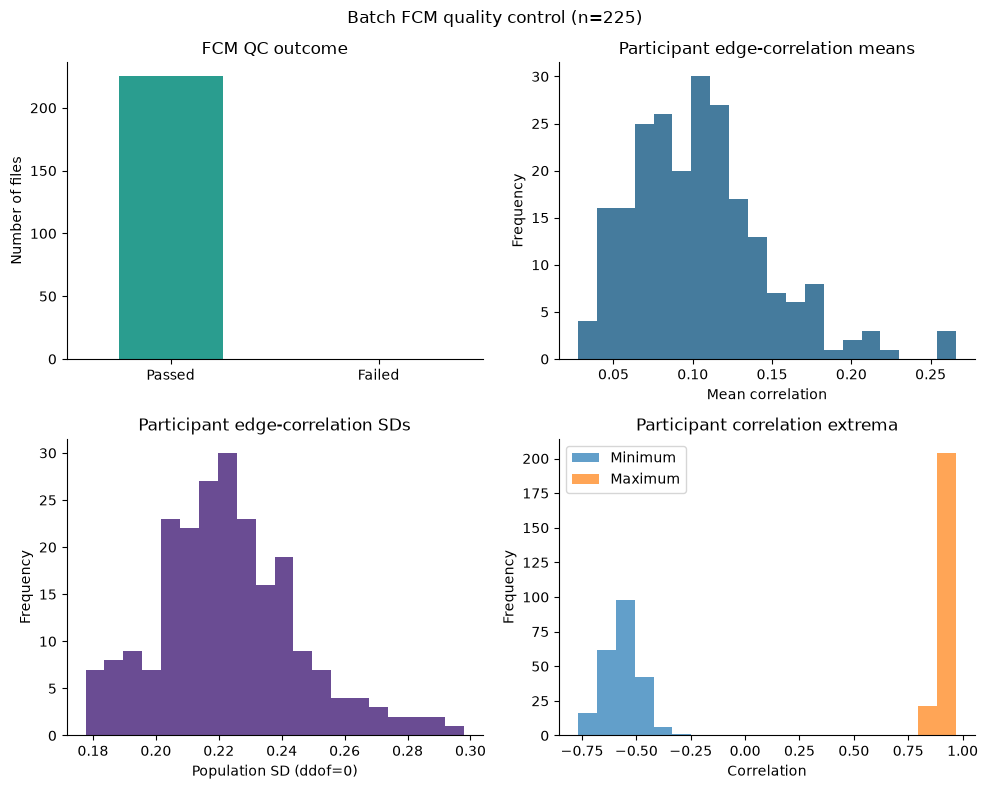

In [6]:
figure_data = qc_results_df.loc[qc_results_df["file_loaded_successfully"]].copy()
pass_counts = pd.Series(
    {
        "Passed": int(qc_results_df["qc_passed"].sum()),
        "Failed": int((~qc_results_df["qc_passed"]).sum()),
    }
)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
pass_counts.plot.bar(ax=axes[0, 0], color=["#2A9D8F", "#E76F51"])
axes[0, 0].set_title("FCM QC outcome")
axes[0, 0].set_ylabel("Number of files")
axes[0, 0].tick_params(axis="x", rotation=0)

figure_data["correlation_mean"].dropna().plot.hist(
    ax=axes[0, 1], bins=20, color="#457B9D"
)
axes[0, 1].set_title("Participant edge-correlation means")
axes[0, 1].set_xlabel("Mean correlation")

figure_data["correlation_std"].dropna().plot.hist(
    ax=axes[1, 0], bins=20, color="#6A4C93"
)
axes[1, 0].set_title("Participant edge-correlation SDs")
axes[1, 0].set_xlabel("Population SD (ddof=0)")

figure_data[["correlation_min", "correlation_max"]].plot.hist(
    ax=axes[1, 1], bins=20, alpha=0.7
)
axes[1, 1].set_title("Participant correlation extrema")
axes[1, 1].set_xlabel("Correlation")
axes[1, 1].legend(["Minimum", "Maximum"])

for axis in axes.flat:
    axis.spines[["top", "right"]].set_visible(False)

fig.suptitle(f"Batch FCM quality control (n={len(qc_results_df)})")
fig.tight_layout()
fig.savefig('../results/batch_fcm_qc_summary.svg', bbox_inches="tight")
plt.show()